In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
!pip install faker
from faker import Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.7 MB/s eta 0:00:00


#`df_personal`

## Data Wrangling

### Gathering Data

In [2]:
df_personal_noisy = pd.read_csv("fintrack_personal_noisy_dataset.csv")
df_personal_noisy.head()

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1.0,2026-04-15,Bensin,Transportasi,Pengeluaran,6024.0,Tunai
1,2.0,2024-11-24,THR,Gaji,Pemasukan,6755121.0,E-Wallet
2,3.0,2025-05-24,Restoran,Makanan & Minuman,Pengeluaran,40610.0,Kartu Debit
3,4.0,2025-06-08,Wifi rumah,Pulsa & Internet,Pengeluaran,274540.0,Kartu Debit
4,5.0,2024-11-26,Subscription,Pembayaran Langganan,Pengeluaran,16504.0,E-Wallet


### Assessing Data

In [3]:
df_personal_noisy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5208 non-null   float64
 1   transaction_date  5215 non-null   object 
 2   description       5189 non-null   object 
 3   category          5250 non-null   object 
 4   transaction_type  5194 non-null   object 
 5   amount            5195 non-null   float64
 6   payment_method    5197 non-null   object 
dtypes: float64(2), object(5)
memory usage: 287.2+ KB


In [4]:
df_personal_noisy.isna().sum()

,0
transaction_id,42
transaction_date,35
description,61
category,0
transaction_type,56
amount,55
payment_method,53


In [5]:
print("Jumlah duplikasi: ", df_personal_noisy.duplicated().sum())

Jumlah duplikasi:  191


In [6]:
df_personal_noisy.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,5208.000000,5215,5189,5250,5194,5.195000e+03,5197
unique,NaN,731,61,9,2,NaN,5
top,NaN,2024-08-21,Transfer,Transfer Teman/Keluarga,Pengeluaran,NaN,Kartu Debit
freq,NaN,16,277,915,4409,NaN,1529
mean,2502.256720,NaN,NaN,NaN,NaN,7.260469e+05,NaN
std,1440.704915,NaN,NaN,NaN,NaN,2.220329e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,-1.040062e+06,NaN
25%,1259.750000,NaN,NaN,NaN,NaN,5.613700e+04,NaN
50%,2504.500000,NaN,NaN,NaN,NaN,1.287410e+05,NaN
75%,3746.250000,NaN,NaN,NaN,NaN,3.151335e+05,NaN


### Cleaning Data


In [7]:
# melihat data mana yang memiliki duplikat
df_personal_noisy[df_personal_noisy.duplicated()]


,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
5000,861.0,2025-02-18,Bioskop,Hiburan,Pengeluaran,50689.0,Transfer Bank
5001,3773.0,2025-07-28,Wifi rumah,Pulsa & Internet,Pengeluaran,43407.0,Kartu Debit
5002,3093.0,2024-06-01,Patungan,Transfer Teman/Keluarga,Pengeluaran,338064.0,Tunai
5003,467.0,2024-11-23,Pembayaran digital,Pembayaran Langganan,Pengeluaran,86550.0,Kartu Kredit
5004,4427.0,2026-02-22,Liburan,Hiburan,Pengeluaran,67146.0,Kartu Debit
...,...,...,...,...,...,...,...
5241,2962.0,2026-05-01,Pulsa,Pulsa & Internet,Pengeluaran,96383.0,Transfer Bank
5242,4974.0,2025-11-05,Air,Tempat Tinggal,NaN,628932.0,E-Wallet
5243,4434.0,2024-07-30,Pulsa,Pulsa & Internet,Pengeluaran,186318.0,Transfer Bank
5247,3792.0,2025-08-28,Patungan,Transfer Teman/Keluarga,Pemasukan,264005.0,Kartu Kredit


In [8]:
# menghapus data duplikat
df_personal_noisy.drop_duplicates(inplace=True)
print("Jumlah duplikasi setelah cleaning: ", df_personal_noisy.duplicated().sum())

Jumlah duplikasi setelah cleaning:  0


In [9]:
# melihat data mana yang memiliki missing value
df_personal_noisy[df_personal_noisy.isna().any(axis=1)]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
15,16.0,2026-03-05,NaN,Tempat Tinggal,Pengeluaran,892842.0,Tunai
21,22.0,2024-08-08,Game online,Hiburan,Pengeluaran,189452.0,NaN
41,NaN,2024-10-21,Ngopi,Makanan & Minuman,Pengeluaran,16529.0,Tunai
59,NaN,2025-11-29,Cloud storage,Pembayaran Langganan,Pengeluaran,130489.0,E-Wallet
64,65.0,2024-09-27,Marketplace,Belanja Bulanan,Pengeluaran,175068.0,NaN
...,...,...,...,...,...,...,...
4984,4985.0,2026-02-06,Gym membership,Pembayaran Langganan,Pengeluaran,147418.0,NaN
4993,4994.0,2026-04-26,Bioskop,Hiburan,Pengeluaran,102295.0,NaN
5013,1185.0,2024-11-21,Paket data,Pulsa & Internet,NaN,74791.0,Kartu Debit
5022,2048.0,2025-09-01,NaN,Pulsa & Internet,Pengeluaran,143607.0,Kartu Kredit


In [10]:
# menghapus missing value pada kolom transaction_date
df_personal_noisy.dropna(subset=['transaction_date'], inplace=True)
print("Jumlah missing value pada kolom transaction_date setelah cleaning: ", df_personal_noisy['transaction_date'].isna().sum())

Jumlah missing value pada kolom transaction_date setelah cleaning:  0


In [11]:
# mengisi missing value pada kolom transaction_id dengan id unik baru
# ambil ID terbesar
max_id = int(df_personal_noisy['transaction_id'].max())

# hitung jumlah missing value
n_missing = df_personal_noisy['transaction_id'].isna().sum()

# buat ID baru unik
new_ids = range(max_id + 1, max_id + 1 + n_missing)

# isi missing value
df_personal_noisy.loc[
    df_personal_noisy['transaction_id'].isna(),
    'transaction_id'
] = list(new_ids)

# ubah tipe data menjadi integer
df_personal_noisy['transaction_id'] = df_personal_noisy['transaction_id'].astype(int)

In [12]:
print("Jumlah missing value pada kolom transaction_id setelah cleaning: ", df_personal_noisy['transaction_id'].isna().sum())

Jumlah missing value pada kolom transaction_id setelah cleaning:  0


In [13]:
# melihat kolom description yang memiliki missing value
df_personal_noisy[df_personal_noisy['description'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
15,16,2026-03-05,NaN,Tempat Tinggal,Pengeluaran,892842.0,Tunai
153,154,2025-01-14,NaN,Belanja Bulanan,Pengeluaran,185293.0,Transfer Bank
391,5005,2025-10-16,NaN,Hiburan,Pengeluaran,66066.0,Kartu Kredit
700,701,2024-09-16,NaN,Pulsa & Internet,Pengeluaran,207124.0,Tunai
786,787,2025-02-03,NaN,Makanan & Minuman,Pengeluaran,54066.0,NaN
833,834,2024-12-21,NaN,Belanja Bulanan,Pengeluaran,164320.0,Kartu Kredit
922,923,2025-03-24,NaN,Tempat Tinggal,Pengeluaran,1287395.0,E-Wallet
999,1000,2025-04-10,NaN,Belanja Bulanan,Pengeluaran,272471.0,E-Wallet
1008,1009,2026-03-16,NaN,Transfer Teman/Keluarga,Pemasukan,182951.0,Transfer Bank
1353,1354,2026-04-22,NaN,Transfer Teman/Keluarga,Pengeluaran,248764.0,Kartu Debit


In [14]:
# mengisi missing value pada kolom description dengan nilai pada kolom category
df_personal_noisy['description'] = df_personal_noisy['description'].fillna(
    df_personal_noisy['category']
)
print("Jumlah missing value pada kolom description setelah cleaning: ", df_personal_noisy['description'].isna().sum())

Jumlah missing value pada kolom description setelah cleaning:  0


In [15]:
# melihat kolom transaction_type yang memiliki missing value
df_personal_noisy[df_personal_noisy['transaction_type'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
151,152,2025-08-24,Bayar teman,Transfer Teman/Keluarga,NaN,291345.0,Kartu Kredit
386,387,2025-06-09,Spotify,Hiburan,NaN,325072.0,Kartu Kredit
399,400,2024-10-31,Gaji bulanan,Gaji,NaN,14234142.0,Kartu Debit
408,409,2025-05-13,Shopee,Belanja Bulanan,NaN,2197296.0,Tunai
877,878,2024-12-31,Bonus,Gaji,NaN,7296425.0,E-Wallet
907,908,2026-03-12,Paket data,Pulsa & Internet,NaN,94878.0,Transfer Bank
914,915,2024-08-08,Patungan,Transfer Teman/Keluarga,NaN,310074.0,Kartu Debit
1019,1020,2025-12-20,Patungan,Transfer Teman/Keluarga,NaN,176178.0,Transfer Bank
1034,1035,2024-12-30,Patungan,Transfer Teman/Keluarga,NaN,513321.0,Kartu Debit
1088,1089,2025-12-03,Makan siang,Makanan & Minuman,NaN,51126.0,Kartu Debit


In [16]:
# mengisi transaction_type yang kosong dengan mapping kolom category
# membuat mapping dari data yang sudah ada
transaction_type_mapping = (
    df_personal_noisy
    .dropna(subset=['transaction_type'])
    .groupby('category')['transaction_type']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

# mengisi missing value pada kolom transaction_type berdasarkan category
mask = df_personal_noisy['transaction_type'].isna()

df_personal_noisy.loc[mask, 'transaction_type'] = (
    df_personal_noisy.loc[mask, 'category']
    .map(transaction_type_mapping)
)

print("Jumlah missing value pada kolom transaction_type setelah cleaning: ", df_personal_noisy['transaction_type'].isna().sum())

Jumlah missing value pada kolom transaction_type setelah cleaning:  0


In [17]:
# mengisi missing value pada kolom payment_method dengan nilai baru "Lainnya"
df_personal_noisy['payment_method'] = df_personal_noisy['payment_method'].fillna('Lainnya')
print("Jumlah missing value pada kolom payment_method setelah cleaning: ", df_personal_noisy['payment_method'].isna().sum())

Jumlah missing value pada kolom payment_method setelah cleaning:  0


In [18]:
# count value kolom payment_method
df_personal_noisy['payment_method'].value_counts()

,count
payment_method,
Kartu Debit,1467
E-Wallet,1208
Tunai,786
Kartu Kredit,768
Transfer Bank,746
Lainnya,50


In [19]:
# melihat nilai yang tidak sesuai pada kolom amount
df_personal_noisy[df_personal_noisy['amount'] < 0]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
90,91,2025-02-06,Beli pakaian,Belanja Bulanan,Pengeluaran,-178657.0,Kartu Debit
149,150,2025-05-28,Restoran,Makanan & Minuman,Pengeluaran,-73588.0,Transfer Bank
184,185,2025-03-11,Tagihan,Tempat Tinggal,Pengeluaran,-138675.0,Tunai
207,208,2026-03-21,Service AC,Tempat Tinggal,Pengeluaran,-1040062.0,Kartu Kredit
425,426,2026-02-08,Transfer,Transfer Teman/Keluarga,Pengeluaran,-537104.0,E-Wallet
...,...,...,...,...,...,...,...
4910,4911,2024-12-05,Listrik,Tempat Tinggal,Pengeluaran,-619445.0,Kartu Debit
5188,1148,2024-09-08,Peralatan rumah,Belanja Bulanan,Pengeluaran,-288346.0,E-Wallet
5206,2920,2026-02-26,Bayar teman,Transfer Teman/Keluarga,Pengeluaran,-225916.0,E-Wallet
5208,1803,2026-03-15,Bayar kos,Tempat Tinggal,Pengeluaran,-835764.0,E-Wallet


In [20]:
# ubah data negatif pada kolom amount menggunakan absolute
df_personal_noisy['amount'] = df_personal_noisy['amount'].abs()

In [21]:
# melihat missing value pada kolom amount
df_personal_noisy[df_personal_noisy['amount'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
160,161,2024-12-28,Bayar kos,Tempat Tinggal,Pengeluaran,NaN,Kartu Kredit
255,256,2025-09-27,GrabFood,Makanan & Minuman,Pengeluaran,NaN,Kartu Debit
417,418,2024-06-23,Liburan,Hiburan,Pengeluaran,NaN,Transfer Bank
527,528,2024-06-06,Ngopi,Makanan & Minuman,Pengeluaran,NaN,E-Wallet
712,713,2025-06-30,Subscription,Pembayaran Langganan,Pengeluaran,NaN,Kartu Debit
761,762,2024-10-18,Spotify,Hiburan,Pengeluaran,NaN,E-Wallet
1153,1154,2024-10-29,Supermarket,Belanja Bulanan,Pengeluaran,NaN,Kartu Debit
1254,1255,2026-02-02,Gym membership,Pembayaran Langganan,Pengeluaran,NaN,Kartu Debit
1349,1350,2025-07-08,Tagihan,Pulsa & Internet,Pengeluaran,NaN,Transfer Bank
1380,1381,2026-01-16,Pembayaran digital,Transfer Teman/Keluarga,Pengeluaran,NaN,E-Wallet


In [22]:
# melakukan drop missing value pada kolom amount
df_personal_noisy.dropna(subset=['amount'], inplace=True)
print("Jumlah missing value pada kolom amount setelah cleaning: ", df_personal_noisy['amount'].isna().sum())

Jumlah missing value pada kolom amount setelah cleaning:  0


In [23]:
df_personal_noisy.isna().sum()

,0
transaction_id,0
transaction_date,0
description,0
category,0
transaction_type,0
amount,0
payment_method,0


In [24]:
# menyimpan dataset clean yang sudah dipreprocessing
df_personal_noisy.to_csv("fintrack_personal_clean_dataset.csv", index=False)

# `df_business`

## Data Wrangling

### Gathering Data

In [25]:
df_business_noisy = pd.read_csv("fintrack_business_noisy_dataset.csv")
df_business_noisy.head()

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1.0,2024-06-09,Pembelian,Piutang,Pemasukan,595193.0,Kartu Debit
1,2.0,2025-01-13,Pmbayaran pelanggan,Piutang,Pemasukan,2104366.0,Transfer Bank
2,3.0,2025-12-04,Pembayaran cicilan,Utang & Cicilan,Pengeluaran,1435766.0,Kartu Debit
3,4.0,2025-04-30,Pendanaan usaha,Modal & Investasi,Pemasukan,5539125.0,E-Wallet
4,5.0,2025-02-12,Refun,Penjualan,Pemasukan,2310919.0,Kartu Debit


### Assessing Data

In [26]:
df_business_noisy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5198 non-null   float64
 1   transaction_date  5202 non-null   object 
 2   description       5203 non-null   object 
 3   category          5250 non-null   object 
 4   transaction_type  5197 non-null   object 
 5   amount            5190 non-null   float64
 6   payment_method    5193 non-null   object 
dtypes: float64(2), object(5)
memory usage: 287.2+ KB


In [27]:
df_business_noisy.isna().sum()

,0
transaction_id,52
transaction_date,48
description,47
category,0
transaction_type,53
amount,60
payment_method,57


In [28]:
print("Jumlah duplikasi: ", df_business_noisy.duplicated().sum())

Jumlah duplikasi:  232


In [29]:
df_business_noisy.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,5198.000000,5202,5203,5250,5197,5.190000e+03,5193
unique,NaN,730,66,14,2,NaN,7
top,NaN,2024-10-11,Pendapatan investasi,Piutang,Pemasukan,NaN,Transfer Bank
freq,NaN,19,278,968,2944,NaN,1415
mean,2504.356291,NaN,NaN,NaN,NaN,4.584456e+06,NaN
std,1439.290664,NaN,NaN,NaN,NaN,9.022712e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,-3.951473e+07,NaN
25%,1264.250000,NaN,NaN,NaN,NaN,8.457538e+05,NaN
50%,2511.500000,NaN,NaN,NaN,NaN,1.944552e+06,NaN
75%,3745.750000,NaN,NaN,NaN,NaN,4.725763e+06,NaN


### Cleaning Data

In [30]:
# melihat data mana yang memiliki duplikat
df_business_noisy[df_business_noisy.duplicated()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
5000,861.0,2024-08-21,Pmbayaran digital,Modal & Investasi,Pemasukan,3516788.0,Tunai
5001,3773.0,2025-12-14,Transfer modal,Modal & Investasi,Pemasukan,3659462.0,Kartu Debit
5002,3093.0,2024-10-21,Restock,Pembelian Stok,Pengeluaran,1693567.0,E-Wallet
5003,467.0,2026-03-17,Pengiriman,Transportasi & Logistik,Pengeluaran,1623203.0,Kartu Kredit
5004,4427.0,2025-11-22,Software bisnis,Software & Langganan,Pengeluaran,5000.0,E-Wallet
...,...,...,...,...,...,...,...
5245,2870.0,2025-08-30,Trf modal,Modal & Investasi,Pemasukan,12492661.0,Kartu Kredit
5246,3235.0,2026-04-29,Tagihan,Pembelian Stok,Pengeluaran,1476658.0,Transfer Bank
5247,3792.0,2024-10-11,Paymnt gateway,Biaya Bank,Pengeluaran,7401.0,Kartu Debit
5248,957.0,2025-12-01,Transfer masuk,Piutang,Pemasukan,1628689.0,Kartu Kredit


In [31]:
# menghapus data duplikat
df_business_noisy.drop_duplicates(inplace=True)
print("Jumlah duplikasi setelah cleaning: ", df_business_noisy.duplicated().sum())

Jumlah duplikasi setelah cleaning:  0


In [32]:
# melihat data mana yang memiliki missing value
df_business_noisy[df_business_noisy.isna().any(axis=1)]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
38,NaN,2025-07-01,QRIS,Peralatan & Aset,Pengeluaran,479849.0,Kartu Debit
39,40.0,2025-07-19,Pmbayaran pelanggan,Piutang,NaN,3489186.0,Transfer Bank
42,43.0,2026-04-20,Transfer masuk,Piutang,Pemasukan,4412605.0,NaN
56,57.0,2024-10-11,Promosi,Marketing & Promosi,Pengeluaran,1207013.0,NaN
63,NaN,2026-01-09,Pmbayaran pelanggan,Piutang,Pemasukan,2195901.0,Kartu Debit
...,...,...,...,...,...,...,...
4870,4871.0,2025-03-20,NaN,Modal & Investasi,Pemasukan,2168090.0,Transfer Bank
4892,4893.0,2026-03-09,Transfer,Pembelian Stok,Pengeluaran,1033518.0,NaN
4913,4914.0,2025-05-05,Pembelian aset,Peralatan & Aset,Pengeluaran,NaN,Kartu Debit
4952,4953.0,NaN,Refund,Lain-lain,NaN,1076261.0,E-Wallet


In [33]:
# menghapus missing value pada kolom transaction_date
df_business_noisy.dropna(subset=['transaction_date'], inplace=True)
print("Jumlah missing value pada kolom transaction_date setelah cleaning: ", df_business_noisy['transaction_date'].isna().sum())

Jumlah missing value pada kolom transaction_date setelah cleaning:  0


In [34]:
# mengisi missing value pada kolom transaction_id dengan id unik baru
# ambil ID terbesar
max_id_business = int(df_business_noisy['transaction_id'].max())

# hitung jumlah missing value
n_missing_business = df_business_noisy['transaction_id'].isna().sum()

# buat ID baru unik
new_ids_business = range(max_id_business + 1, max_id_business + 1 + n_missing_business)

# isi missing value
df_business_noisy.loc[
    df_business_noisy['transaction_id'].isna(),
    'transaction_id'
] = list(new_ids_business)

# ubah tipe data menjadi integer
df_business_noisy['transaction_id'] = df_business_noisy['transaction_id'].astype(int)

In [35]:
print("Jumlah missing value pada kolom transaction_id setelah cleaning: ", df_business_noisy['transaction_id'].isna().sum())

Jumlah missing value pada kolom transaction_id setelah cleaning:  0


In [36]:
# melihat kolom description yang memiliki missing value
df_business_noisy[df_business_noisy['description'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
111,112,2024-11-01,NaN,Gaji & Karyawan,Pengeluaran,5319456.0,QRIS
292,293,2025-06-22,NaN,Piutang,Pemasukan,1934787.0,Transfer Bank
441,442,2025-01-25,NaN,Transportasi & Logistik,Pengeluaran,-458181.0,Kartu Kredit
449,450,2025-12-21,NaN,Modal & Investasi,Pemasukan,3777929.0,Kartu Kredit
538,539,2025-11-30,NaN,Piutang,Pemasukan,5023994.0,Transfer Bank
627,628,2024-09-26,NaN,Peralatan & Aset,Pengeluaran,3125088.0,Kartu Debit
651,652,2025-01-13,NaN,Piutang,Pemasukan,1896627.0,Tunai
678,679,2025-04-23,NaN,Penjualan,Pemasukan,390407.0,Transfer Bank
1016,1017,2025-06-16,NaN,Modal & Investasi,Pemasukan,26517550.0,E-Wallet
1204,1205,2026-04-22,NaN,Penjualan,Pemasukan,2019538.0,Transfer Bank


In [37]:
# mengisi missing value pada kolom description dengan nilai pada kolom category
df_business_noisy['description'] = df_business_noisy['description'].fillna(
    df_business_noisy['category']
)
print("Jumlah missing value pada kolom description setelah cleaning: ", df_business_noisy['description'].isna().sum())

Jumlah missing value pada kolom description setelah cleaning:  0


In [38]:
# melihat kolom transaction_type yang memiliki missing value
df_business_noisy[df_business_noisy['transaction_type'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
39,40,2025-07-19,Pmbayaran pelanggan,Piutang,NaN,3489186.0,Transfer Bank
216,217,2025-06-04,Paymnt gateway,Gaji & Karyawan,NaN,1034726.0,Transfer Bank
397,398,2025-08-09,Biaya transaksi,Biaya Bank,NaN,15365.0,E-Wallet
415,416,2026-01-25,Bonus,Gaji & Karyawan,NaN,13230243.0,E-Wallet
453,454,2025-02-12,Pendanaan usaha,Modal & Investasi,NaN,3717232.0,Transfer Bank
575,576,2025-07-12,Marketplace,Penjualan,NaN,3671501.0,E-Wallet
707,708,2025-06-12,Pembelian barang,Pembelian Stok,NaN,NaN,Kartu Kredit
755,756,2026-02-10,Biaya tak terduga,Lain-lain,NaN,321847.0,Transfer Bank
936,937,2026-04-21,Koreksi transaksi,Lain-lain,NaN,335132.0,E-Wallet
943,944,2024-07-05,Biaya tak terduga,Lain-lain,NaN,308661.0,Kartu Debit


In [39]:
# mengisi transaction_type yang kosong dengan mapping kolom category
# membuat mapping dari data yang sudah ada
business_transaction_type_mapping = (
    df_business_noisy
    .dropna(subset=['transaction_type'])
    .groupby('category')['transaction_type']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

# mengisi missing value pada kolom transaction_type berdasarkan category
mask_business_ttype = df_business_noisy['transaction_type'].isna()

df_business_noisy.loc[mask_business_ttype, 'transaction_type'] = (
    df_business_noisy.loc[mask_business_ttype, 'category']
    .map(business_transaction_type_mapping)
)

print("Jumlah missing value pada kolom transaction_type setelah cleaning: ", df_business_noisy['transaction_type'].isna().sum())

Jumlah missing value pada kolom transaction_type setelah cleaning:  0


In [40]:
# mengisi missing value pada kolom payment_method dengan nilai baru "Lainnya"
df_business_noisy['payment_method'] = df_business_noisy['payment_method'].fillna('Lainnya')
print("Jumlah missing value pada kolom payment_method setelah cleaning: ", df_business_noisy['payment_method'].isna().sum())

Jumlah missing value pada kolom payment_method setelah cleaning:  0


In [41]:
# count value kolom payment_method
df_business_noisy['payment_method'].value_counts()

,count
payment_method,
Transfer Bank,1340
Kartu Debit,1074
E-Wallet,895
Kartu Kredit,604
Tunai,395
Payment Gateway,346
QRIS,264
Lainnya,53


In [42]:
# melihat nilai yang tidak sesuai pada kolom amount (nilai negatif)
df_business_noisy[df_business_noisy['amount'] < 0]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
34,35,2025-09-23,Promosi,Marketing & Promosi,Pengeluaran,-989150.0,Kartu Kredit
55,56,2025-08-04,Iklan,Transportasi & Logistik,Pengeluaran,-451156.0,Transfer Bank
99,100,2025-02-28,Payment gateway,Biaya Bank,Pengeluaran,-24428.0,Kartu Kredit
143,144,2024-07-01,Cloud service,Software & Langganan,Pengeluaran,-5000.0,QRIS
194,195,2025-01-11,Operasional kendaraan,Transportasi & Logistik,Pengeluaran,-217320.0,Kartu Debit
...,...,...,...,...,...,...,...
5049,776,2025-09-08,Bonus,Gaji & Karyawan,Pengeluaran,-7046136.0,Tunai
5124,3158,2026-02-19,Cashback,Pembelian Stok,Pengeluaran,-364775.0,Tunai
5144,4745,2025-12-08,Pembayaran,Lain-lain,Pengeluaran,-172710.0,Tunai
5229,3992,2025-09-12,Pembayaran,Gaji & Karyawan,Pengeluaran,-8969219.0,E-Wallet


In [43]:
# ubah data negatif pada kolom amount menggunakan absolute
df_business_noisy['amount'] = df_business_noisy['amount'].abs()

In [44]:
# melihat missing value pada kolom amount
df_business_noisy[df_business_noisy['amount'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
127,128,2025-09-09,Pelunasan,Piutang,Pemasukan,NaN,QRIS
547,548,2024-07-06,Peralatan bisnis,Peralatan & Aset,Pengeluaran,NaN,Kartu Debit
574,575,2024-11-06,Pmbayaran pelanggan,Piutang,Pemasukan,NaN,Transfer Bank
597,598,2024-12-12,Pendapatan investasi,Modal & Investasi,Pemasukan,NaN,Kartu Kredit
692,693,2024-12-25,Transfer masuk,Piutang,Pemasukan,NaN,Transfer Bank
707,708,2025-06-12,Pembelian barang,Pembelian Stok,Pengeluaran,NaN,Kartu Kredit
736,737,2025-06-23,Promosi,Marketing & Promosi,Pengeluaran,NaN,Payment Gateway
746,747,2026-03-04,Payment gateway,Biaya Bank,Pengeluaran,NaN,Payment Gateway
810,811,2024-10-24,Marketplace,Penjualan,Pemasukan,NaN,E-Wallet
885,886,2025-10-17,Pendapatan online,Penjualan,Pemasukan,NaN,Transfer Bank


In [45]:
# mengisi missing value dengan median berdasarkan mapping kolom description
# membuat mapping description -> median amount
business_amount_mapping = (
    df_business_noisy
    .dropna(subset=['amount'])
    .groupby('description')['amount']
    .median()
    .to_dict()
)

# mencari missing value
mask_business_amount = df_business_noisy['amount'].isna()

# mengisi missing amount berdasarkan description
df_business_noisy.loc[mask_business_amount, 'amount'] = (
    df_business_noisy.loc[mask_business_amount, 'description']
    .map(business_amount_mapping)
)

print("Jumlah missing value pada kolom amount setelah cleaning: ", df_business_noisy['amount'].isna().sum())

Jumlah missing value pada kolom amount setelah cleaning:  0


In [46]:
# drop missing value
df_business_noisy.dropna(inplace=True)
df_business_noisy.isna().sum()

,0
transaction_id,0
transaction_date,0
description,0
category,0
transaction_type,0
amount,0
payment_method,0


In [47]:
# menyimpan dataset clean yang sudah dipreprocessing
df_business_noisy.to_csv("fintrack_business_clean_dataset.csv", index=False)

# Explaratory Data Analysis

Pertanyaan Bisnis
1. Apakah pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan selama 2 tahun terakhir?
2. Bagaimana kondisi arus kas bisnis selama 2 tahun terakhir, dan kategori biaya bisnis apa yang paling besar mengurangi keuntungan bulanan?

In [48]:
# memanggil data yang sudah dilakukan proses cleaning
data_personal = pd.read_csv("/content/fintrack_personal_clean_dataset.csv")
data_bisnis = pd.read_csv("/content/fintrack_business_clean_dataset.csv")

In [49]:
data_personal.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,4973.000000,4973,4973,4973,4973,4.973000e+03,4973
unique,NaN,731,70,9,2,NaN,6
top,NaN,2024-08-21,Transfer,Transfer Teman/Keluarga,Pengeluaran,NaN,Kartu Debit
freq,NaN,15,267,861,4227,NaN,1450
mean,2520.712045,NaN,NaN,NaN,NaN,7.437647e+05,NaN
std,1456.190469,NaN,NaN,NaN,NaN,2.250004e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,3.042000e+03,NaN
25%,1258.000000,NaN,NaN,NaN,NaN,5.839200e+04,NaN
50%,2517.000000,NaN,NaN,NaN,NaN,1.318550e+05,NaN
75%,3782.000000,NaN,NaN,NaN,NaN,3.212110e+05,NaN


In [50]:
data_bisnis.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,4971.000000,4971,4971,4971,4971,4.971000e+03,4971
unique,NaN,730,75,14,2,NaN,8
top,NaN,2025-07-06,Pendapatan investasi,Piutang,Pemasukan,NaN,Transfer Bank
freq,NaN,17,259,926,2808,NaN,1340
mean,2529.916918,NaN,NaN,NaN,NaN,4.693786e+06,NaN
std,1456.699391,NaN,NaN,NaN,NaN,8.871598e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,3.619000e+03,NaN
25%,1270.500000,NaN,NaN,NaN,NaN,8.988965e+05,NaN
50%,2533.000000,NaN,NaN,NaN,NaN,1.983132e+06,NaN
75%,3792.500000,NaN,NaN,NaN,NaN,4.797618e+06,NaN


mengelompokkan pemasukan dan pendapatan seetiap bulan (df_personal)

In [51]:
# mengubah tanggal menjadi datetime
data_personal['transaction_date'] = pd.to_datetime(data_personal['transaction_date'])
data_personal['month'] = data_personal['transaction_date'].dt.to_period('M')
data_bisnis['transaction_date'] = pd.to_datetime(data_bisnis['transaction_date'])
data_bisnis['month'] = data_bisnis['transaction_date'].dt.to_period('M')

In [52]:
# mengelompokkan pemasukan dan pengeluaran seetiap bulan (df_personal)
monthly_summary = data_personal.groupby(['month', 'transaction_type']).agg({
    'amount': ['sum', 'mean']
}).reset_index()
monthly_summary.head()

month transaction_type       amount              
                                     sum          mean
0  2024-05        Pemasukan    5714442.0  2.857221e+06
1  2024-05      Pengeluaran    7038661.0  2.270536e+05
2  2024-06        Pemasukan  117286274.0  3.665196e+06
3  2024-06      Pengeluaran   32814454.0  2.063802e+05
4  2024-07        Pemasukan  164716104.0  4.844591e+06

In [53]:
# membuat pivot table dan rasio antara pengeluaran dan pemasukan tiap bulan
monthly_summary = data_personal.pivot_table(
    index='month',
    columns='transaction_type',
    values='amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

# tambah kolom rasio
monthly_summary['rasio_pengeluaran (%)'] = (
    monthly_summary['Pengeluaran'] /
    monthly_summary['Pemasukan']
) * 100

monthly_summary

transaction_type,month,Pemasukan,Pengeluaran,rasio_pengeluaran (%)
0,2024-05,5714442.0,7038661.0,123.173199
1,2024-06,117286274.0,32814454.0,27.978085
2,2024-07,164716104.0,48245898.0,29.290335
3,2024-08,102091966.0,44603358.0,43.689391
4,2024-09,177225281.0,32474681.0,18.323955
5,2024-10,212048163.0,40702288.0,19.194832
6,2024-11,115218903.0,38959138.0,33.813148
7,2024-12,133592688.0,35865390.0,26.846821
8,2025-01,73443322.0,46709071.0,63.598799
9,2025-02,83990294.0,37695289.0,44.880530


In [54]:
# rata-rata rasio_pengeluaran selama 2 tahun belakangan
monthly_summary['rasio_pengeluaran (%)'].mean()


np.float64(39.91811103174754)

mengelompokkan pemasukan dan pendapatan seetiap bulan (df_bisnis)

In [55]:
# mengelompokkan pemasukan dan pengeluaran seetiap bulan (df_bisnis)
monthly_summary_bisnis = data_bisnis.groupby(['month', 'transaction_type']).agg({
    'amount': ['sum', 'mean']
}).reset_index()
monthly_summary_bisnis.head()

month transaction_type       amount              
                                     sum          mean
0  2024-05        Pemasukan  137855238.0  5.993706e+06
1  2024-05      Pengeluaran   39079333.0  1.776333e+06
2  2024-06        Pemasukan  645267999.0  5.761321e+06
3  2024-06      Pengeluaran  191215804.5  2.223440e+06
4  2024-07        Pemasukan  532792797.0  4.367154e+06

In [56]:
# membuat pivot table dan rasio antara pengeluaran dan pemasukan tiap bulan
monthly_summary_bisnis = data_bisnis.pivot_table(
    index='month',
    columns='transaction_type',
    values='amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

# tambah kolom rasio
monthly_summary_bisnis['rasio_pengeluaran (%)'] = (
    monthly_summary_bisnis['Pengeluaran'] /
    monthly_summary_bisnis['Pemasukan']
) * 100

monthly_summary_bisnis

transaction_type,month,Pemasukan,Pengeluaran,rasio_pengeluaran (%)
0,2024-05,1.378552e+08,39079333.0,28.348094
1,2024-06,6.452680e+08,191215804.5,29.633548
2,2024-07,5.327928e+08,219191093.0,41.140026
3,2024-08,7.200076e+08,318607792.0,44.250616
4,2024-09,8.836522e+08,252862755.0,28.615641
5,2024-10,8.464068e+08,280874338.0,33.184321
6,2024-11,6.788416e+08,272109573.0,40.084397
7,2024-12,5.510005e+08,235174834.0,42.681422
8,2025-01,4.972804e+08,281055101.0,56.518435
9,2025-02,5.119085e+08,123063901.0,24.040215


In [57]:
# rata-rata rasio_pengeluaran selama 2 tahun belakangan
monthly_summary_bisnis['rasio_pengeluaran (%)'].mean()


np.float64(36.70606617198346)

In [58]:
# melihat kategori pengeluran yang paling besar tiap bulan (top 3)
# filter hanya pengeluaran
pengeluaran = data_bisnis[
    data_bisnis['transaction_type'] == 'Pengeluaran'
]

# groupby bulan dan kategori pengeluaran
top_pengeluaran = pengeluaran.groupby(
    ['month', 'category']
)['amount'].sum().reset_index()

# urutkan dari terbesar
top_pengeluaran = top_pengeluaran.sort_values(
    ['month', 'amount'],
    ascending=[True, False]
)

# ambil top 3 tiap bulan
top_3_pengeluaran = top_pengeluaran.groupby('month').head(3)
top_3_pengeluaran

,month,category,amount
2,2024-05,Operasional Kantor,16238244.0
3,2024-05,Peralatan & Aset,9062514.0
0,2024-05,Lain-lain,5609707.0
12,2024-06,Operasional Kantor,42709040.0
8,2024-06,Gaji & Karyawan,36222772.0
...,...,...,...
264,2026-04,Gaji & Karyawan,67362283.0
267,2026-04,Operasional Kantor,47998060.0
282,2026-05,Peralatan & Aset,109631166.0
276,2026-05,Gaji & Karyawan,42264565.0


In [59]:
# count value category pada df top_3_pengeluaran
top_3_pengeluaran['category'].value_counts()

,count
category,
Gaji & Karyawan,24
Peralatan & Aset,21
Operasional Kantor,10
Utang & Cicilan,8
Pajak & Perizinan,6
Pembelian Stok,3
Lain-lain,1
Transportasi & Logistik,1
Marketing & Promosi,1


Insight:

dari (df_personal)
1. Selama 2 tahun terakhir pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan.
2. Rata-rata pengeluaran pengguna selama 2 tahun terakhir yakni 13.6% dari total pemasukan pengguna.

dari (df_bisnis)
1. Selama 2 tahun terakhir, kondisi arus kas bisnis tergolong sehat, dengan rasio rata-rata pengeluaran sebesar 34.7% dari total pendapatan.
2. Kategori pengeluaran bisnis yang memiliki nominal paling besar cukup beragam tiap bulan. Namun selama 2 tahun terakhir kategori (Pajak & Perizinan), (Peralatan & Aset), dan (Utang & Cicilan) yang paling sering muncul dan memiliki nominal besar

# Classification

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [61]:
data = pd.read_csv("/content/fintrack_business_clean_dataset.csv")
data.head(10)

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1,2024-06-09,Pembelian,Piutang,Pemasukan,595193.0,Kartu Debit
1,2,2025-01-13,Pmbayaran pelanggan,Piutang,Pemasukan,2104366.0,Transfer Bank
2,3,2025-12-04,Pembayaran cicilan,Utang & Cicilan,Pengeluaran,1435766.0,Kartu Debit
3,4,2025-04-30,Pendanaan usaha,Modal & Investasi,Pemasukan,5539125.0,E-Wallet
4,5,2025-02-12,Refun,Penjualan,Pemasukan,2310919.0,Kartu Debit
5,6,2024-09-19,Pendapatan online,Penjualan,Pemasukan,355364.0,Kartu Kredit
6,7,2025-02-25,Transfer masuk,Piutang,Pemasukan,771225.0,E-Wallet
7,8,2026-02-06,Pengiriman,Transportasi & Logistik,Pengeluaran,1281768.0,Transfer Bank
8,9,2025-09-26,Pendanaan usaha,Modal & Investasi,Pemasukan,5175389.0,Transfer Bank
9,10,2025-10-17,Pembayaran pelanggan,Piutang,Pemasukan,1616565.0,Kartu Debit


In [62]:
# drop variabel transaction_id dan transaction_date
dataa = data.drop(columns=['transaction_id','transaction_date'])
dataa

,description,category,transaction_type,amount,payment_method
0,Pembelian,Piutang,Pemasukan,595193.0,Kartu Debit
1,Pmbayaran pelanggan,Piutang,Pemasukan,2104366.0,Transfer Bank
2,Pembayaran cicilan,Utang & Cicilan,Pengeluaran,1435766.0,Kartu Debit
3,Pendanaan usaha,Modal & Investasi,Pemasukan,5539125.0,E-Wallet
4,Refun,Penjualan,Pemasukan,2310919.0,Kartu Debit
...,...,...,...,...,...
4966,Perizinan,Pajak & Perizinan,Pengeluaran,3677586.0,Kartu Debit
4967,Transfer masuk,Piutang,Pemasukan,890369.0,Tunai
4968,Pembayaran,Gaji & Karyawan,Pengeluaran,8969219.0,E-Wallet
4969,Peralatan bisnis,Peralatan & Aset,Pengeluaran,1134206.0,E-Wallet


In [63]:
## Buat instance LabelEncoder
label_encoder = LabelEncoder()

## List kolom kategorikal yang perlu di-encode
categorical_columns = ['description','transaction_type', 'payment_method']

## Encode kolom kategorikal
for column in categorical_columns:
    dataa[column] = label_encoder.fit_transform(dataa[column])

dataa.head(15)

,description,category,transaction_type,amount,payment_method
0,37,Piutang,0,595193.0,1
1,54,Piutang,0,2104366.0,6
2,32,Utang & Cicilan,1,1435766.0,1
3,40,Modal & Investasi,0,5539125.0,0
4,58,Penjualan,0,2310919.0,1
5,42,Penjualan,0,355364.0,2
6,68,Piutang,0,771225.0,0
7,44,Transportasi & Logistik,1,1281768.0,6
8,40,Modal & Investasi,0,5175389.0,6
9,35,Piutang,0,1616565.0,1


In [64]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom numerik
numeric_columns = dataa.select_dtypes(include=['int64', 'float64']).columns
dataa[numeric_columns] = scaler.fit_transform(dataa[numeric_columns])

# Pisahkan fitur (X) dan target (y)
X = dataa.drop(columns=['category'])
y = dataa['category']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(3976, 4), y_train=(3976,)
Test set shape: X_test=(995, 4), y_test=(995,)


In [65]:
# Model Training
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

## Decision Tree

In [66]:
# DT

## Evaluasi model train
y_pred_dt = dt.predict(X_train)
cm_dt = confusion_matrix(y_train, y_pred_dt)
print(cm_dt, '\n')

acc_dt_train = accuracy_score(y_train, y_pred_dt)
print("Accuracy:", acc_dt_train)

prec_dt_train = precision_score(
    y_train,
    y_pred_dt,
    average='weighted'
)
print("Precision:", prec_dt_train)

rec_dt_train = recall_score(y_train, y_pred_dt, average='weighted')
print("Recall (train):", rec_dt_train)

[[150   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 172   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 154   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 183   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 708   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 165   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 146   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 182   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 741   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 187   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 739   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 155   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 147   0]
 [  0   0   0   0   0   0   0   0   0   0   1   0   0 146]] 

Accuracy: 0.9997484909456741
Precision: 0.9997488308227744
Recall (train): 0.9997484909456741


In [67]:
# DT
## Evaluasi model test
y_pred_dt1 = dt.predict(X_test)
cm_dt1 = confusion_matrix(y_test, y_pred_dt1)
print(cm_dt1, '\n')

acc_dt_test = accuracy_score(y_test, y_pred_dt1)
print("Accuracy (test):", acc_dt_test)

prec_dt_test = precision_score(y_test, y_pred_dt1, average='weighted')
print("Precision (test):", prec_dt_test)

rec_dt_test = recall_score(y_test, y_pred_dt1, average='weighted')
print("Recall (test):", rec_dt_test)

[[ 34   0   0   1   1   0   0   0   1   2   1   1   1   0]
 [  0  34   1   1   0   0   0   0   0   2   1   1   0   2]
 [  1   0  44   0   0   2   0   0   1   0   1   4   2   0]
 [  3   0   0  25   0   0   0   2   1   1   2   1   3   0]
 [  1   1   2   1 150   0   2   1   7   0   3   1   0   2]
 [  1   1   3   2   2  32   0   0   1   2   1   2   0   3]
 [  0   0   1   0   1   1  35   1   0   0   0   0   2   2]
 [  0   2   1   0   1   0   0  45   0   0   0   1   1   0]
 [  0   1   0   0   5   0   0   0 152   0  11   1   0   2]
 [  0   3   0   0   0   0   0   0   0  26   1   1   2   0]
 [  0   0   0   0   7   3   0   3  16   3 154   0   0   1]
 [  0   0   0   0   2   0   1   4   0   0   0  24   2   0]
 [  0   1   4   1   0   1   0   2   1   2   3   0  30   0]
 [  0   2   1   1   0   1   2   0   1   1   1   0   1  22]] 

Accuracy (test): 0.8110552763819096
Precision (test): 0.8133778114659921
Recall (test): 0.8110552763819096


## Random Forest

In [68]:
# RF

## Evaluasi model train
y_pred_rf = rf.predict(X_train)
cm_rf = confusion_matrix(y_train, y_pred_rf)
print(cm_rf, '\n')

acc_rf_train = accuracy_score(y_train, y_pred_rf)
print("Accuracy:", acc_rf_train)

prec_rf_train = precision_score(
    y_train,
    y_pred_rf,
    average='weighted'
)
print("Precision:", prec_rf_train)

rec_rf_train = recall_score(y_train, y_pred_rf, average='weighted')
print("Recall (train):", rec_rf_train)

[[150   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 172   0   0   0   0   0   0   0   0   0   0   0   0]
 [  1   0 153   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 183   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 708   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 165   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 146   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 182   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 741   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 187   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 739   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 155   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 147   0]
 [  0   0   0   0   0   0   0   0   0   0   1   0   0 146]] 

Accuracy: 0.9994969818913481
Precision: 0.9994989873913249
Recall (train): 0.9994969818913481


In [69]:
# RF
## Evaluasi model test
y_pred_rf1 = rf.predict(X_test)
cm_rf1 = confusion_matrix(y_test, y_pred_rf1)
print(cm_rf1, '\n')

acc_rf_test = accuracy_score(y_test, y_pred_rf1)
print("Accuracy (test):", acc_rf_test)

prec_rf_test = precision_score(y_test, y_pred_rf1, average='weighted')
print("Precision (test):", prec_rf_test)

rec_rf_test = recall_score(y_test, y_pred_rf1, average='weighted')
print("Recall (test):", rec_rf_test)

[[ 35   0   1   0   2   1   0   0   1   1   0   0   1   0]
 [  0  33   2   3   0   0   0   0   0   0   1   0   0   3]
 [  2   1  43   0   0   3   1   1   1   0   1   2   0   0]
 [  1   0   1  23   0   2   1   2   1   1   1   1   4   0]
 [  0   1   2   0 159   0   0   1   4   0   4   0   0   0]
 [  1   1   3   3   2  32   0   0   1   2   1   1   1   2]
 [  0   1   1   2   1   1  28   2   0   1   0   0   4   2]
 [  0   0   1   0   1   0   0  44   0   4   0   1   0   0]
 [  0   1   0   0   2   0   0   0 151   0  16   1   0   1]
 [  0   1   0   1   1   0   0   2   0  24   0   1   1   2]
 [  0   0   0   0   7   1   0   1  14   2 162   0   0   0]
 [  0   0   0   1   2   1   2   4   0   0   0  23   0   0]
 [  2   1   1   1   0   0   1   3   0   5   2   1  27   1]
 [  0   8   1   1   0   1   1   0   1   0   1   1   0  18]] 

Accuracy (test): 0.8060301507537688
Precision (test): 0.8060047006942963
Recall (test): 0.8060301507537688


#Data Visualization

1. Apakah pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan selama dua tahun terakhir?


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

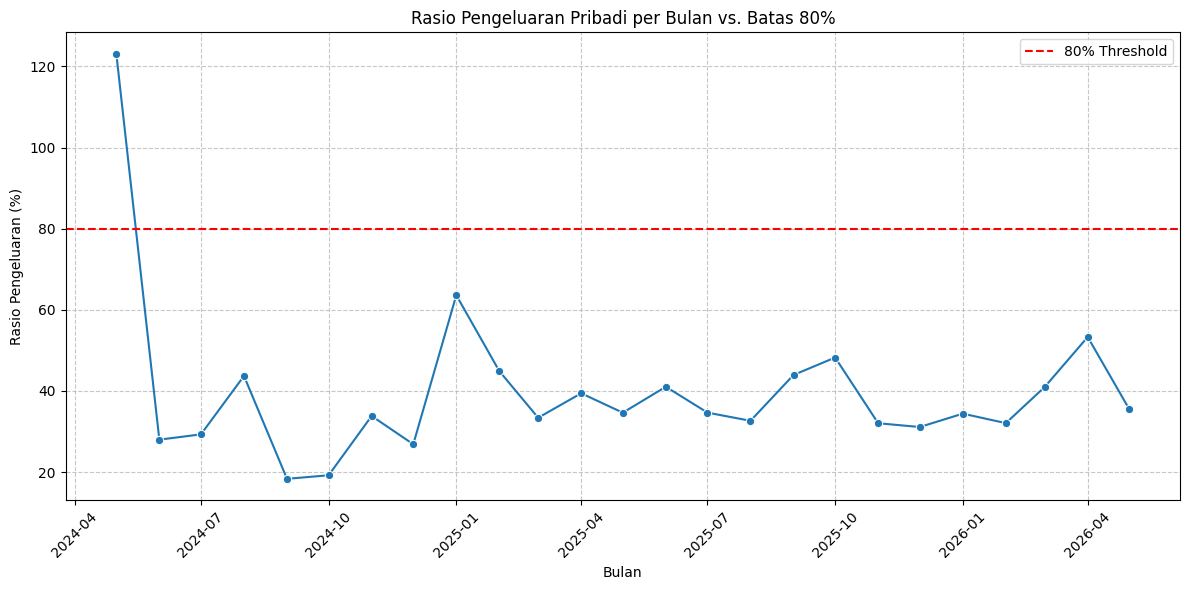

In [71]:
# Convert 'month' Period objects to datetime objects for plotting, if they are not already datetime
if isinstance(monthly_summary['month'].dtype, pd.PeriodDtype):
    monthly_summary['month'] = monthly_summary['month'].dt.to_timestamp()
if isinstance(monthly_summary_bisnis['month'].dtype, pd.PeriodDtype):
    monthly_summary_bisnis['month'] = monthly_summary_bisnis['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='rasio_pengeluaran (%)', data=monthly_summary, marker='o')
plt.axhline(y=80, color='r', linestyle='--', label='80% Threshold')
plt.title('Rasio Pengeluaran Pribadi per Bulan vs. Batas 80%')
plt.xlabel('Bulan')
plt.ylabel('Rasio Pengeluaran (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print('\n')

2. Bagaimana kondisi arus kas bisnis selama dua tahun terakhir, dan kategori biaya bisnis apa yang paling besar mengurangi keuntungan bulanan?

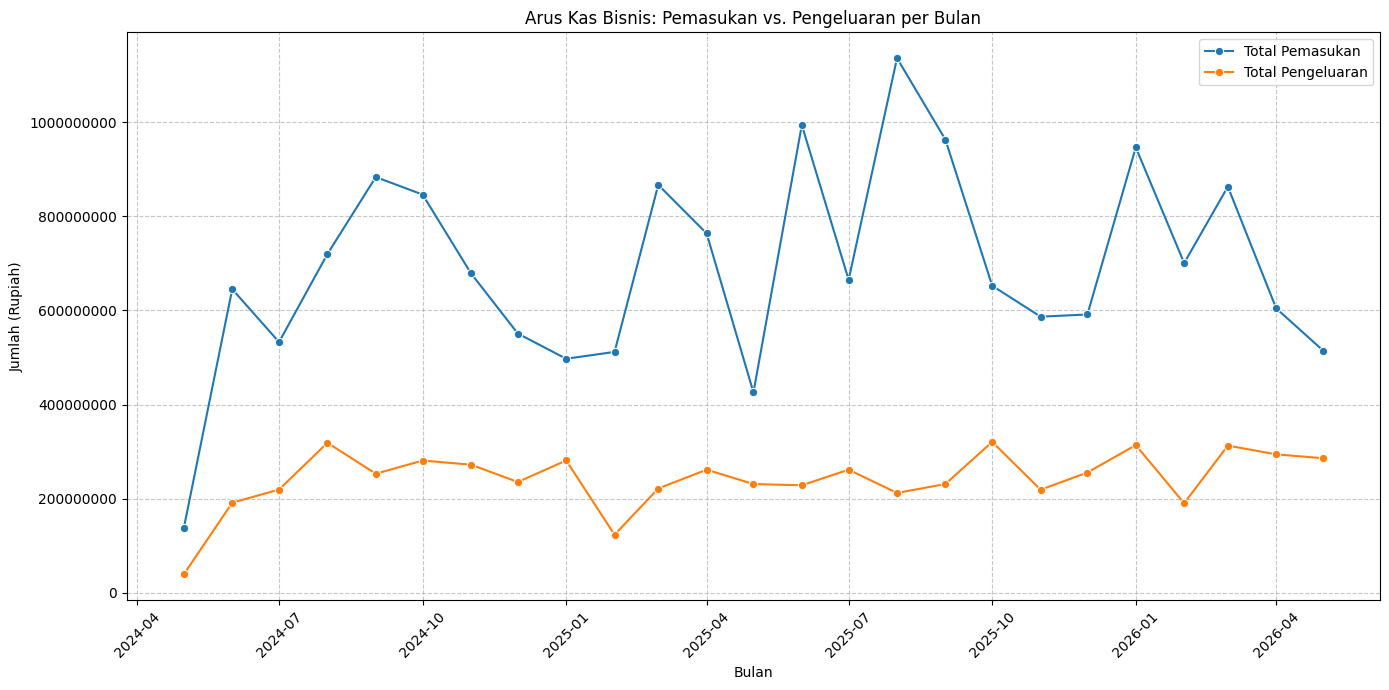

In [72]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='Pemasukan', data=monthly_summary_bisnis, label='Total Pemasukan', marker='o')
sns.lineplot(x='month', y='Pengeluaran', data=monthly_summary_bisnis, label='Total Pengeluaran', marker='o')
plt.title('Arus Kas Bisnis: Pemasukan vs. Pengeluaran per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah (Rupiah)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print('\n')

/tmp/ipykernel_7907/4216439385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_3_pengeluaran['month'] = top_3_pengeluaran['month'].dt.to_timestamp()


<Figure size 1500x800 with 0 Axes>

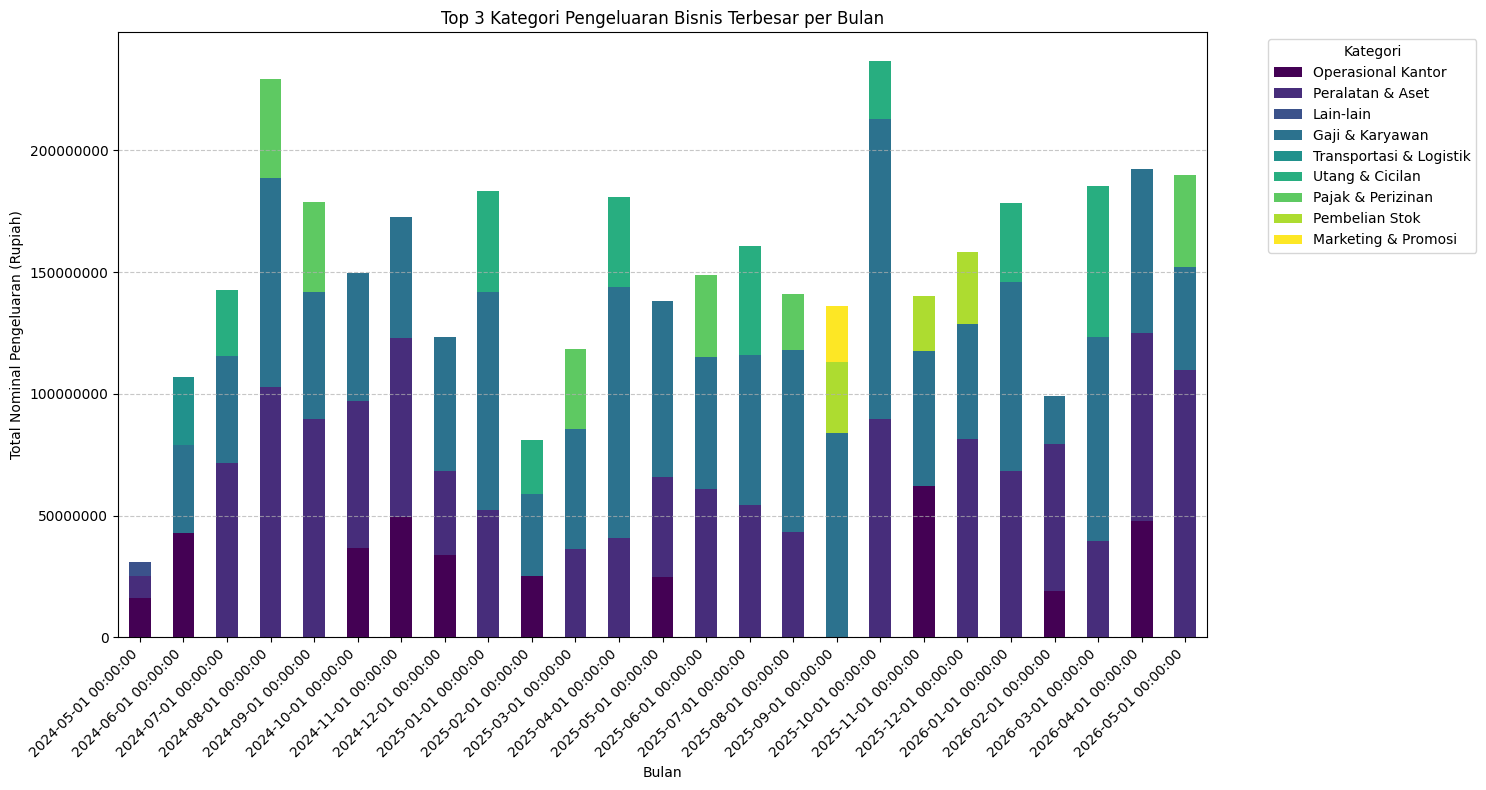

In [73]:
# Convert 'month' Period objects to datetime objects for plotting
if isinstance(top_3_pengeluaran['month'].dtype, pd.PeriodDtype):
    top_3_pengeluaran['month'] = top_3_pengeluaran['month'].dt.to_timestamp()

# Pivot the table to get categories as columns for stacking
pivoted_top_3_pengeluaran = top_3_pengeluaran.pivot_table(
    index='month',
    columns='category',
    values='amount',
    fill_value=0
)

# Sort the columns to ensure consistent stacking order (optional, but good practice)
pivoted_top_3_pengeluaran = pivoted_top_3_pengeluaran.reindex(
    columns=top_3_pengeluaran['category'].unique()
)

plt.figure(figsize=(15, 8))
ax = pivoted_top_3_pengeluaran.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')

plt.title('Top 3 Kategori Pengeluaran Bisnis Terbesar per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Nominal Pengeluaran (Rupiah)')
plt.ticklabel_format(style='plain', axis='y') # Avoid scientific notation on y-axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

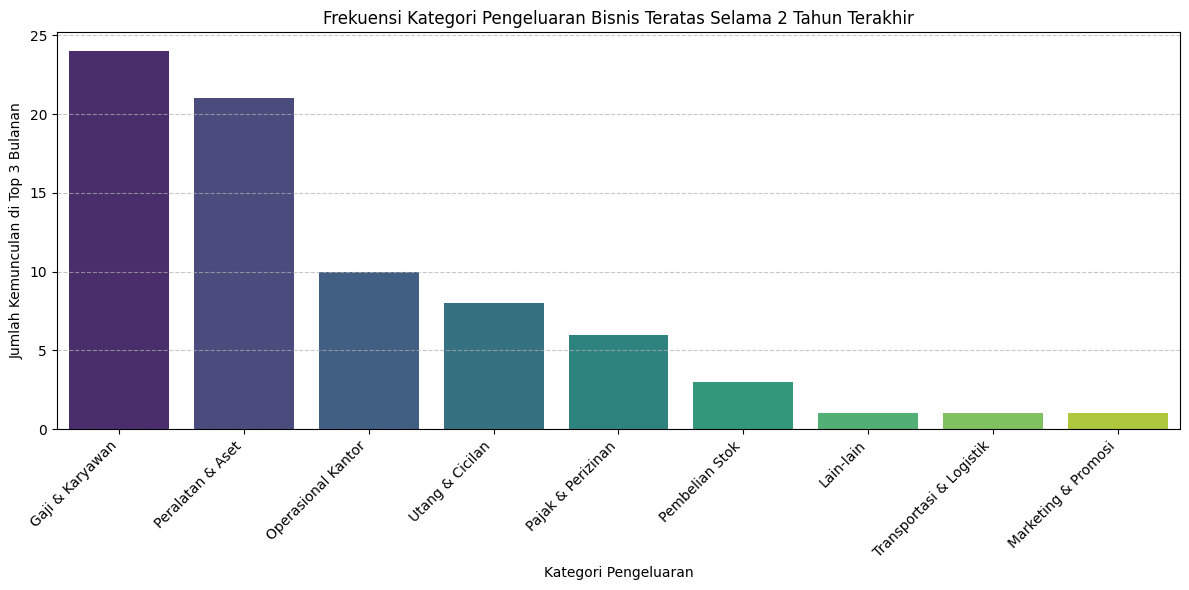

In [74]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_3_pengeluaran['category'].value_counts().index,
            y=top_3_pengeluaran['category'].value_counts().values,
            hue=top_3_pengeluaran['category'].value_counts().index, legend=False,
            palette='viridis')
plt.title('Frekuensi Kategori Pengeluaran Bisnis Teratas Selama 2 Tahun Terakhir')
plt.xlabel('Kategori Pengeluaran')
plt.ylabel('Jumlah Kemunculan di Top 3 Bulanan')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()